In [2]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
import recharge_funcs as rf

In [3]:
models=["UKESM1-0-LL", "MRI-ESM2-0", "MPI-ESM1-2-HR", "GFDL-ESM4", "IPSL-CM6A-LR", "CNRM-CM6-1", "CanESM5", "MIROC6", "TaiESM1", "EC-Earth3"]
scenarios = ["historical", "ssp126", "ssp245", "ssp370", "ssp585"]

#station coordinates
station_locations = pd.read_csv("mHM_eval_stations.csv")
#Boundaries data
be_shp = gpd.read_file(r"W:/VUB/_main_research/mHM/mhm_belgium/be_shp/be.shp")

#rivers
# rivers_shp = gpd.read_file(r"W:/VUB/_main_research/data/shapefiles/HydroRIVERS_v10_eu_shp/HydroRIVERS_v10_eu_shp/hydroRivers_BE.shp")

#eval stations pickle path
base_data_dir = r"D:\VUB\_data\_isimip_3b\bias_corrected\meteo"

#### Read model scenarios and compute ensemble mean

In [4]:
#read scenarios data
def read_scenario_data(models, scenarios, var, base_data_dir):
    model_scenario_data = {}
    for model in models:
        for scen in scenarios:
            file_path = os.path.join(base_data_dir, f"{model}/{scen}/{var}.nc")
            if os.path.exists(file_path):
                ds = xr.open_dataset(file_path)
                ds_BE = rf.clip_to_region(be_shp, ds)

                ds_actual = ds_BE[var].where(ds_BE[var].var(dim="time") > 0.0001)

                da = ds_actual.to_dataset(name=var)
                model_scenario_data[f"{model}_{scen}_{var}"] = da

    return model_scenario_data

#compute ensemble mean per scenario
def compute_ensemble_mean(model_scenario_data, var):
    ensemble_mean_proportions = {}
    for scen in scenarios:
        scen_datasets = [ds[var] for key, ds in model_scenario_data.items() if scen in key and var in key]
        if scen_datasets:
            combined = xr.concat(scen_datasets, dim="model") #concatenate along a new 'model' dimension
            ensemble_mean = combined.mean(dim="model") #compute mean across models
            ensemble_mean_proportions[scen] = ensemble_mean
    return ensemble_mean_proportions

In [5]:
#example usage
variables= ["pre", 'pet', 'tavg']
#dict of processed data for all variables, models, and scenarios
var_dict = {}
for var in variables:
    var_data = read_scenario_data(models, scenarios, var, base_data_dir)
    var_ensemble_mean = compute_ensemble_mean(var_data, var)
    var_dict[var] = var_ensemble_mean

### Changes in variable between scenarios

In [6]:

#function to compute mean monthly values across years and gridcells for each scenario
def compute_monthly_climatology(var_dict, var, scenarios, historical_slice, future_slice):
    monthly_clim = {}
    for scen in scenarios:
        if scen=='historical':
            var_data = var_dict[var][scen].sel(time=historical_slice)
        else:
            var_data = var_dict[var][scen].sel(time=future_slice)
        
        #compute mean monthly values across years
        #for temperature we compute mean monthly values across years, 
        # for PET and pre we first aggregate daily values to monthly sums, then compute mean across years
        if var == 'tavg':
            var_monthly = var_data.groupby("time.month").mean(dim="time")
        else:
            var_monthly = var_data.resample(time="ME").sum().groupby("time.month").mean(dim="time")
            var_monthly = var_monthly.where(var_monthly != 0)
        
        var_monthly_df = var_monthly.mean(dim=["lat", "lon"]).to_dataframe().reset_index()
        var_monthly_df['month'] = var_monthly_df['month'].astype(int)
        #map month numbers to month names
        month_mapping = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
        var_monthly_df['month'] = var_monthly_df['month'].map(month_mapping)
        #select only month and variable columns
        var_monthly_df = var_monthly_df[['month', var]]
        #set month as index
        var_monthly_df.set_index('month', inplace=True)

        monthly_clim[scen] = var_monthly_df
    return monthly_clim

In [7]:

#start and end years for historical and future scenarios
historical_slice = slice("1971", "2000")
future_slice = slice("2071", "2100")
var_dict = var_dict
variables = ["pre", 'pet', 'tavg']

all_vars_monthly_clim = {}
for var in variables:
    var_monthly_clim = compute_monthly_climatology(var_dict, var, scenarios, historical_slice, future_slice)
    print(f"Monthly climatology for {var}:")
    all_vars_monthly_clim[var] = var_monthly_clim

Monthly climatology for pre:
Monthly climatology for pet:
Monthly climatology for tavg:


### Plots

In [8]:
#rename scenarios in dict to Historical, SSP3-7.0, SSP5-8.5
scenario_mapping = {
    "historical": "Historical",
    "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",
    "ssp370": "SSP3-7.0",
    "ssp585": "SSP5-8.5"

}
all_vars_monthly_clim_renamed = {}
for var, scen_dict in all_vars_monthly_clim.items():
    renamed_dict = {scenario_mapping[scen]: df for scen, df in scen_dict.items()}
    all_vars_monthly_clim_renamed[var] = renamed_dict

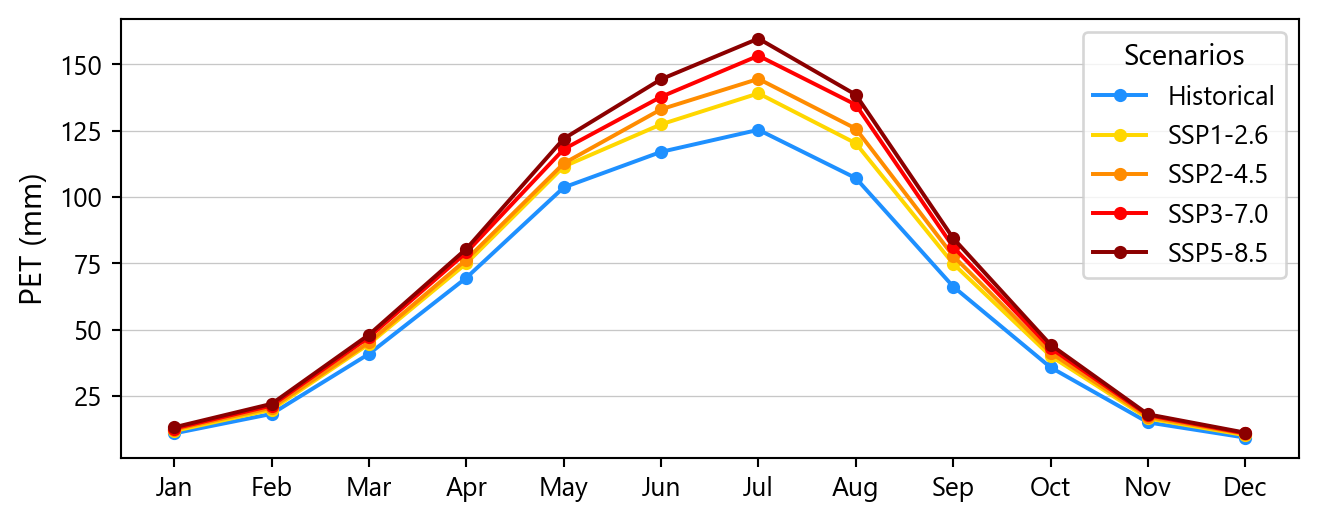

In [19]:
scenarios_renamed = [scenario_mapping[scen] for scen in scenarios]

#plot PET for all scenarios going from historical to future scenarios using a cool to warm color scheme
colors = ['dodgerblue', 'gold', 'darkorange', 'red', 'darkred']  # Define colors for each scenario

plt.figure(figsize=(8, 3.0), dpi=190)
for scen in scenarios_renamed:
    plt.plot(all_vars_monthly_clim_renamed['pet'][scen]['pet'], label=scen, 
             color=colors[scenarios_renamed.index(scen)], marker='o', markersize=4)
plt.ylabel("PET (mm)", fontsize=12)
plt.grid(axis='y', alpha=0.7, lw=0.5)
plt.legend(fontsize=10, title="Scenarios", title_fontsize=11, ncol=1, loc='upper right')

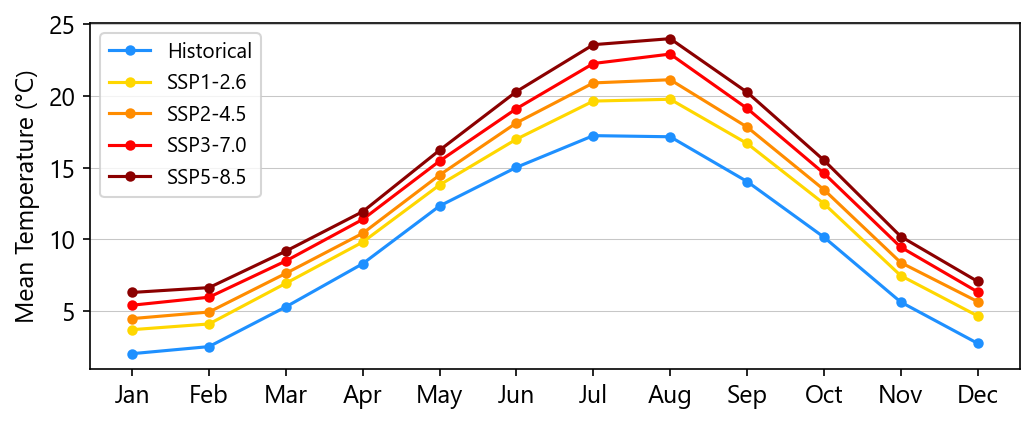

In [20]:
#plot tavg for all scenarios
plt.figure(figsize=(8, 3), dpi=150)

for scen in scenarios_renamed:
    plt.plot(all_vars_monthly_clim_renamed['tavg'][scen]['tavg'], label=scen, 
             color=colors[scenarios_renamed.index(scen)], marker='o', markersize=4)
plt.ylabel("Mean Temperature (°C)", fontsize=12)
plt.grid(axis='y', alpha=0.7, lw=0.5)
plt.legend(fontsize=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12);

In [39]:
seasons = {
    'Winter': ['Dec', 'Jan', 'Feb'],
    'Spring': ['Mar', 'Apr', 'May'],
    'Summer': ['Jun', 'Jul', 'Aug'],
    'Autumn': ['Sep', 'Oct', 'Nov']
}

scenario_changes = {}
for scenario in scenarios_renamed:
    mon_change = (all_vars_monthly_clim_renamed['tavg'][scenario] -all_vars_monthly_clim_renamed['tavg']['Historical'])
    scenario_changes[scenario] = mon_change

seasonal_changes = {}
for season, months in seasons.items():
    seasonal_changes[season] = {scenario: scenario_changes[scenario].loc[months].sum() for scenario in scenario_changes}

In [40]:
scenario_changes

{'Historical':        tavg
 month      
 Jan     0.0
 Feb     0.0
 Mar     0.0
 Apr     0.0
 May     0.0
 Jun     0.0
 Jul     0.0
 Aug     0.0
 Sep     0.0
 Oct     0.0
 Nov     0.0
 Dec     0.0,
 'SSP1-2.6':            tavg
 month          
 Jan    1.671932
 Feb    1.577034
 Mar    1.643566
 Apr    1.505548
 May    1.465403
 Jun    1.961545
 Jul    2.408213
 Aug    2.612736
 Sep    2.650398
 Oct    2.336313
 Nov    1.839444
 Dec    1.910067,
 'SSP2-4.5':            tavg
 month          
 Jan    2.444068
 Feb    2.408054
 Mar    2.335068
 Apr    2.118303
 May    2.156889
 Jun    3.097173
 Jul    3.673323
 Aug    3.973989
 Sep    3.794455
 Oct    3.309695
 Nov    2.749307
 Dec    2.908441,
 'SSP3-7.0':            tavg
 month          
 Jan    3.376105
 Feb    3.440536
 Mar    3.198365
 Apr    3.086335
 May    3.131608
 Jun    4.088700
 Jul    5.025494
 Aug    5.761526
 Sep    5.095404
 Oct    4.447006
 Nov    3.824078
 Dec    3.582684,
 'SSP5-8.5':            tavg
 month          
 Jan

#### Water Availability

In [23]:
### Calculate pre-PET for all scenarios
pre_pet_clim = {}
for scen in scenarios_renamed:
    pre_clim = all_vars_monthly_clim_renamed['pre'][scen]
    pet_clim = all_vars_monthly_clim_renamed['pet'][scen]
    pre_pet = pre_clim['pre'] - pet_clim['pet']
    pre_pet.columns = ['month','wb']
    pre_pet_clim[scen] = pre_pet

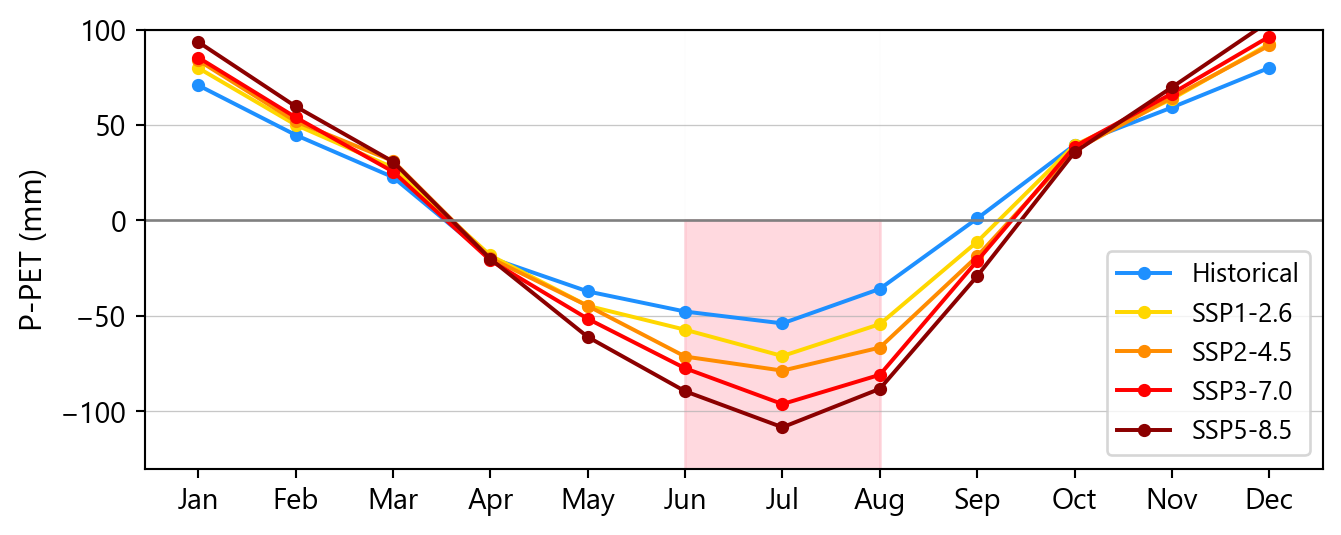

In [24]:
#plot p-pet for all scenarios
plt.figure(figsize=(8, 3), dpi=190)
for scen in scenarios_renamed:
    plt.plot(pre_pet_clim[scen], label=scen, color=colors[scenarios_renamed.index(scen)], marker='o', markersize=4)
plt.axhline(0, color='gray', lw=1)  # Add a horizontal line at y=0 for reference

#vertical lines from month names June to August with shaded area for summer season
plt.axvline(x='Jun', color='gray', lw=0.01)
plt.axvline(x='Aug', color='gray', lw=0.01)
plt.fill_betweenx(y=[-130, 0], x1='Jun', x2='Aug', color='pink', alpha=0.6)
plt.ylim(-130, 100)
plt.grid(axis='y', alpha=0.7, lw=0.5)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11);
plt.ylabel("P-PET (mm)", fontsize=12)
plt.legend(loc='lower right', fontsize=10, ncol=1)

In [25]:
pre_pet_clim['SSP5-8.5'] - pre_pet_clim['Historical']

#group by season and compute mean pre-pet for each season and scenario
pre_pet_clim_seasonal = {}
for scen in scenarios_renamed:
    pre_pet_clim_seasonal[scen] = {}
    for season, months in seasons.items():
        pre_pet_clim_seasonal[scen][season] = pre_pet_clim[scen].loc[months].mean()

In [26]:
pre_pet_clim

{'Historical': month
 Jan    70.805436
 Feb    44.771619
 Mar    22.668927
 Apr   -19.593750
 May   -37.185383
 Jun   -47.731774
 Jul   -53.940062
 Aug   -35.861612
 Sep     1.024143
 Oct    39.523866
 Nov    59.213019
 Dec    79.983148
 dtype: float64,
 'SSP1-2.6': month
 Jan    79.879020
 Feb    50.099810
 Mar    27.716571
 Apr   -18.341823
 May   -44.730697
 Jun   -57.262389
 Jul   -71.043807
 Aug   -54.324975
 Sep   -11.170837
 Oct    39.421338
 Nov    63.655475
 Dec    92.431435
 dtype: float64,
 'SSP2-4.5': month
 Jan    83.897718
 Feb    51.880603
 Mar    31.135601
 Apr   -19.767127
 May   -44.763680
 Jun   -71.315593
 Jul   -78.699005
 Aug   -66.627458
 Sep   -18.795139
 Oct    36.832878
 Nov    64.374893
 Dec    91.685584
 dtype: float64,
 'SSP3-7.0': month
 Jan    85.372021
 Feb    54.035495
 Mar    25.575187
 Apr   -20.962097
 May   -51.530386
 Jun   -77.469158
 Jul   -96.220674
 Aug   -80.885351
 Sep   -21.224917
 Oct    38.718992
 Nov    66.517211
 Dec    96.337548
 dtype:

In [27]:
pre_pet_clim_seasonal

{'Historical': {'Winter': 65.18673446865473,
  'Spring': -11.370068503400887,
  'Summer': -45.84448302757068,
  'Autumn': 33.25367620917303},
 'SSP1-2.6': {'Winter': 74.13675498124549,
  'Spring': -11.785316362747743,
  'Summer': -60.87705706111708,
  'Autumn': 30.635325359991622},
 'SSP2-4.5': {'Winter': 75.82130152784774,
  'Spring': -11.131735224277937,
  'Summer': -72.21401857344807,
  'Autumn': 27.470877197026976},
 'SSP3-7.0': {'Winter': 78.58168776819464,
  'Spring': -15.639098678100117,
  'Summer': -84.85839419231205,
  'Autumn': 28.003762185548897},
 'SSP5-8.5': {'Winter': 85.86693136369665,
  'Spring': -16.802873143185415,
  'Summer': -95.37338087952666,
  'Autumn': 25.43542471414788}}